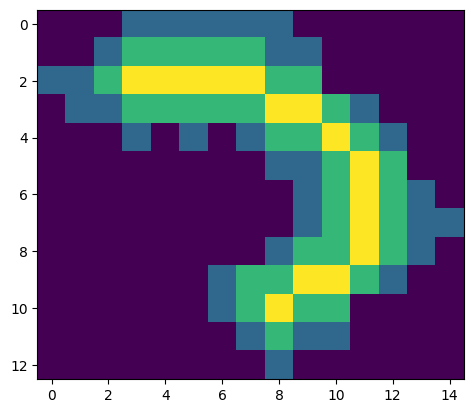

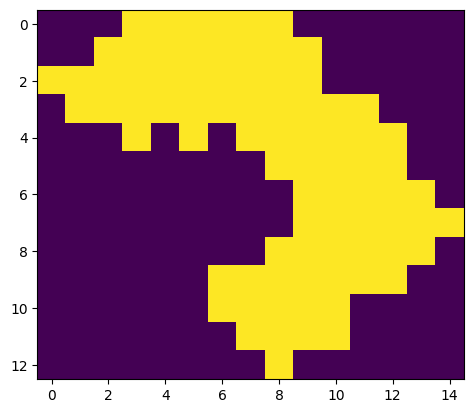

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from topostats.tracing.tracedna import traceDNA

def plot(img):
    plt.imshow(img)
    plt.show()

original = np.array(
    [
        [0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 2, 2, 2, 2, 2, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 2, 3, 3, 3, 3, 3, 2, 2, 0, 0, 0, 0, 0],
        [0, 1, 1, 2, 2, 2, 2, 2, 3, 3, 2, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 0, 1, 2, 2, 3, 2, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 3, 2, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 2, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 2, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 3, 2, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 2, 2, 3, 3, 2, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 2, 3, 2, 2, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    ]
)

mask = original.astype(bool)

plt.imshow(original)
plt.show()
plt.imshow(mask)

[Wed, 07 Jun 2023 18:41:42] [INFO    ] [topostats] Tracing DNA
[Wed, 07 Jun 2023 18:41:42] [INFO    ] [topostats] Applying gaussian blur
unordered coordinates: [[2, 0], [2, 1], [2, 2], [2, 3], [2, 4], [2, 5], [2, 6], [2, 7], [3, 8], [4, 9], [5, 10], [6, 10], [7, 10], [8, 10], [9, 7], [9, 9], [10, 8]]
points with one neighbour: [[2 0]
 [9 7]]
starting point: [2, 0]
coordinates after initial point deletion: [[2, 1], [2, 2], [2, 3], [2, 4], [2, 5], [2, 6], [2, 7], [3, 8], [4, 9], [5, 10], [6, 10], [7, 10], [8, 10], [9, 7], [9, 9], [10, 8]]
number_of_neighbours for [2, 0]: 1, neighbours: [[2, 1]]
number_of_neighbours for [2, 1]: 1, neighbours: [[2, 2]]
number_of_neighbours for [2, 2]: 1, neighbours: [[2, 3]]
number_of_neighbours for [2, 3]: 1, neighbours: [[2, 4]]
number_of_neighbours for [2, 4]: 1, neighbours: [[2, 5]]
number_of_neighbours for [2, 5]: 1, neighbours: [[2, 6]]
number_of_neighbours for [2, 6]: 1, neighbours: [[2, 7]]
number_of_neighbours for [2, 7]: 1, neighbours: [[3, 8]]
n

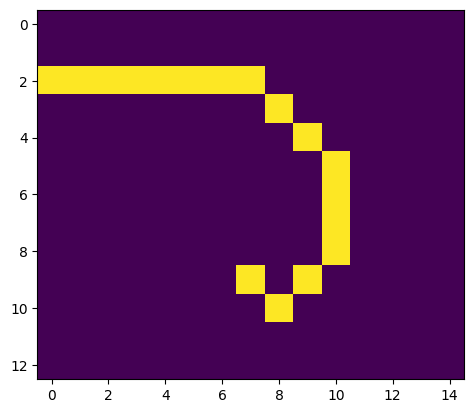

In [2]:
tracedna = traceDNA(
    grain_image=original,
    grain_mask=mask,
    filename="FILENAME",
    pixel_to_nm_scaling=0.5,
)
tracedna.trace_dna()

plt.imshow(tracedna.grain["skeleton"])

# Order the trace
traceDNA.reorder_linear_trace(tracedna.grain["skeleton"])

[[0 0 0 0 0 0 1 2 2 2 1 0 0 0 0]
 [2 3 3 3 3 3 4 4 6 3 2 0 0 0 0]
 [1 2 2 2 2 2 3 3 5 3 3 0 0 0 0]
 [2 3 3 3 3 3 3 3 4 3 3 1 0 0 0]
 [0 0 0 0 0 0 0 0 1 3 2 2 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 2 3 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 2 3 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 2 3 0 0 0]
 [0 0 0 0 0 0 1 1 2 3 2 2 0 0 0]
 [0 0 0 0 0 0 1 1 3 2 2 1 0 0 0]
 [0 0 0 0 0 0 1 2 2 2 1 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


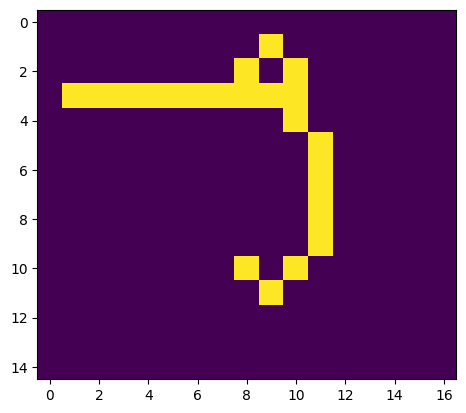

In [11]:



skeleton = tracedna.grain["skeleton"].copy()

padded = np.pad(skeleton, 1, mode="constant")
plt.imshow(padded)
top_left = padded[:-2, :-2]
top_center = padded[:-2, 1:-1]
top_right = padded[:-2, 2:]
middle_left = padded[1:-1, :-2]
middle_right = padded[1:-1, 2:]
bottom_left = padded[2:, :-2]
bottom_center = padded[2:, 1:-1]
bottom_right = padded[2:, 2:]

adjacent = sum(
    [
        top_left,
        top_center,
        top_right,
        middle_left,
        middle_right,
        bottom_left,
        bottom_center,
        bottom_right,
    ]
)
print(adjacent)

In [3]:
arr = np.array(
    [
        [0, 1],
        [2, 3],
        [4, 5],
        [6, 7]
    ]
)

np.delete(arr, np.where((arr==[2, 3]).all(axis=1)), axis=0)


lst = [[2, 3], [4, 6], [3, 8]]
lst.remove([4, 6])